In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

from hbn.visualization import visualize

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

%matplotlib inline

#pio.renderers.default = 'iframe'
import plotly.io as pio
pio.renderers.default='notebook'

In [2]:
### FUNCTIONS ###

def get_data(dirn='/Users/maedbhking/Documents/hbn_data', 
             models=['adhd-total_scores_demographics-models'],
             diagnosis_file='Clinical_Diagnosis_Demographics.csv'
            ):
    # check ADHD models ('adhd-basic_demographics-models')
    from hbn.models.predictive_modeling import check_models

    # hard code model diretory
    df_all = pd.DataFrame()
    for model in models:
        df = check_models(dirn=os.path.join(dirn, 'models'), 
                    diagnosis_file=os.path.join(dirn, diagnosis_file),
                    filter=f'*{model}/*')
        df['participant_group'] = df['sex'] + '_' + df['age']
        df['model_name'] = model
        df_all = pd.concat([df_all, df])

    return df_all

## Check ADHD age models

In [57]:
# get data
df_all = get_data(dirn='/Users/maedbhking/Documents/hbn_data',
                 models=['adhd-age-basic_demographics-models'],
                 )

In [4]:
# set plotting style
visualize.plotting_style()

## Age

<Axes: xlabel='age', ylabel='roc_auc_score'>

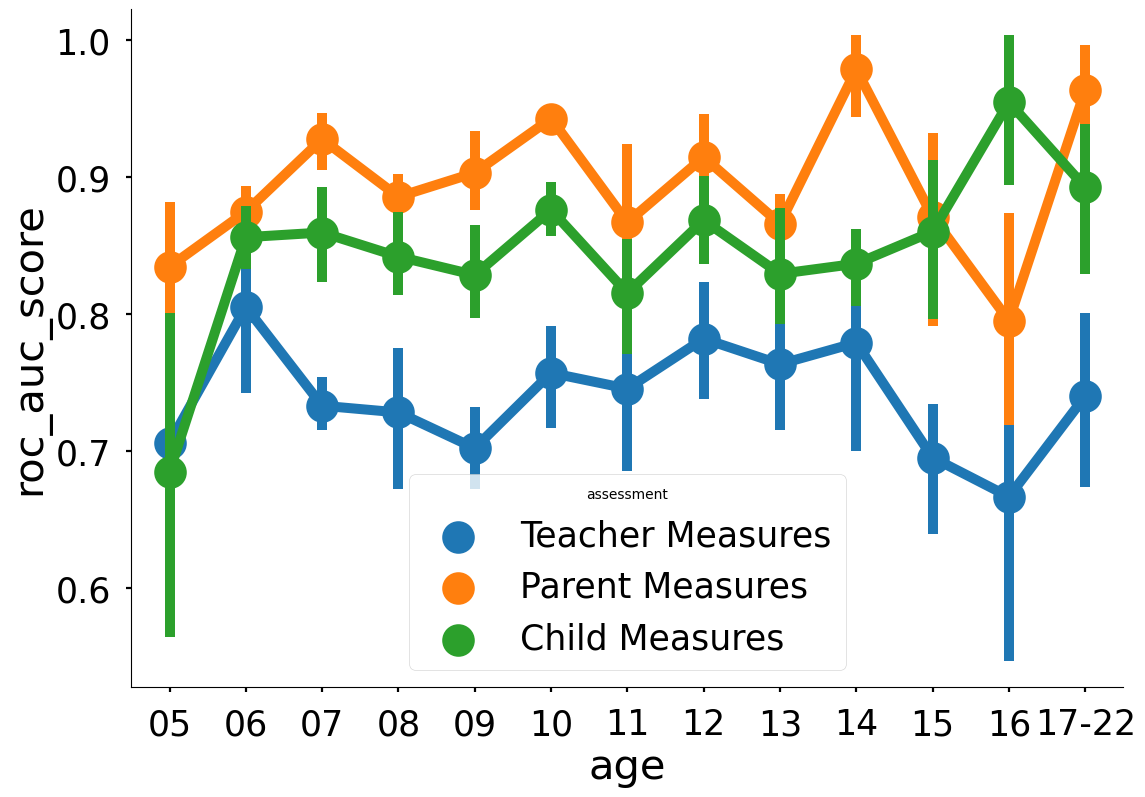

In [5]:
ages_to_keep = ['05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17-22']

df1 = df_all[(df_all['sex'].isin(['all'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment'].isin(['Parent Measures', 'Child Measures', 'Teacher Measures']))
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='assessment', data=df1, order=sorted(df1['age'].unique()))

<Axes: xlabel='age', ylabel='roc_auc_score'>

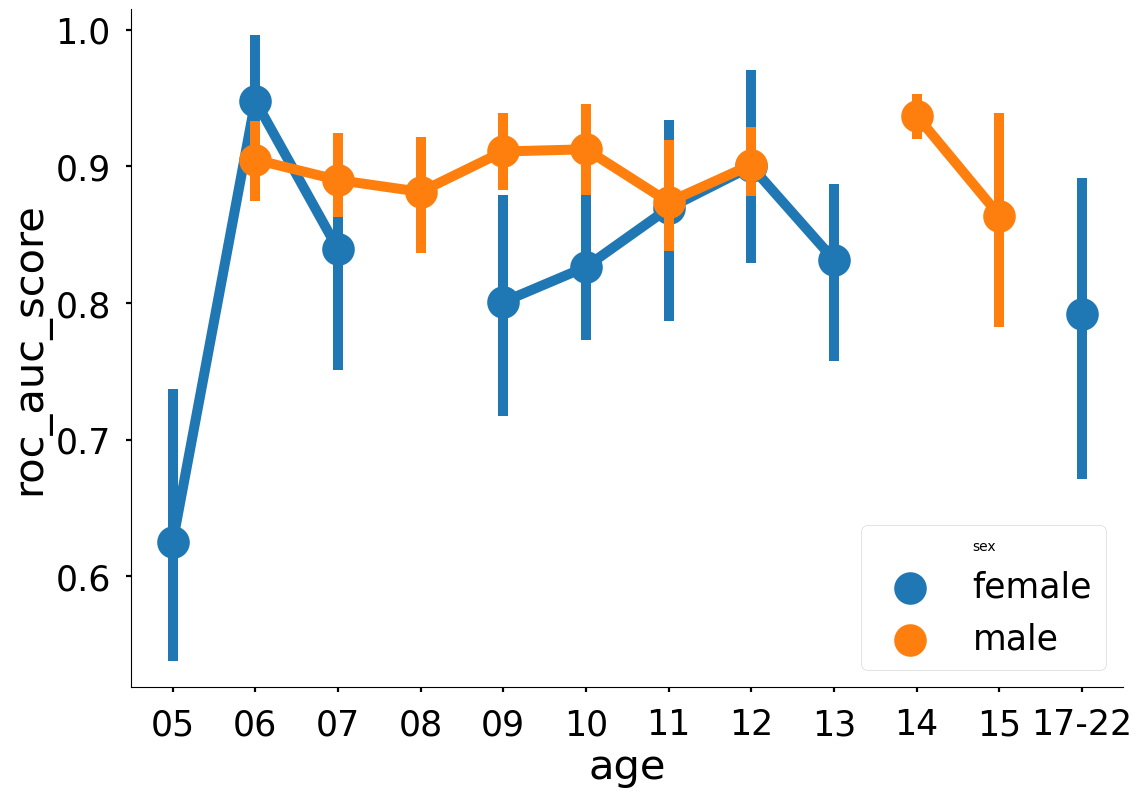

In [6]:
ages_to_keep = ['05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17-22']


df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment']=='all')
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='sex', data=df1, order=sorted(df1['age'].unique()))

<Axes: xlabel='age', ylabel='roc_auc_score'>

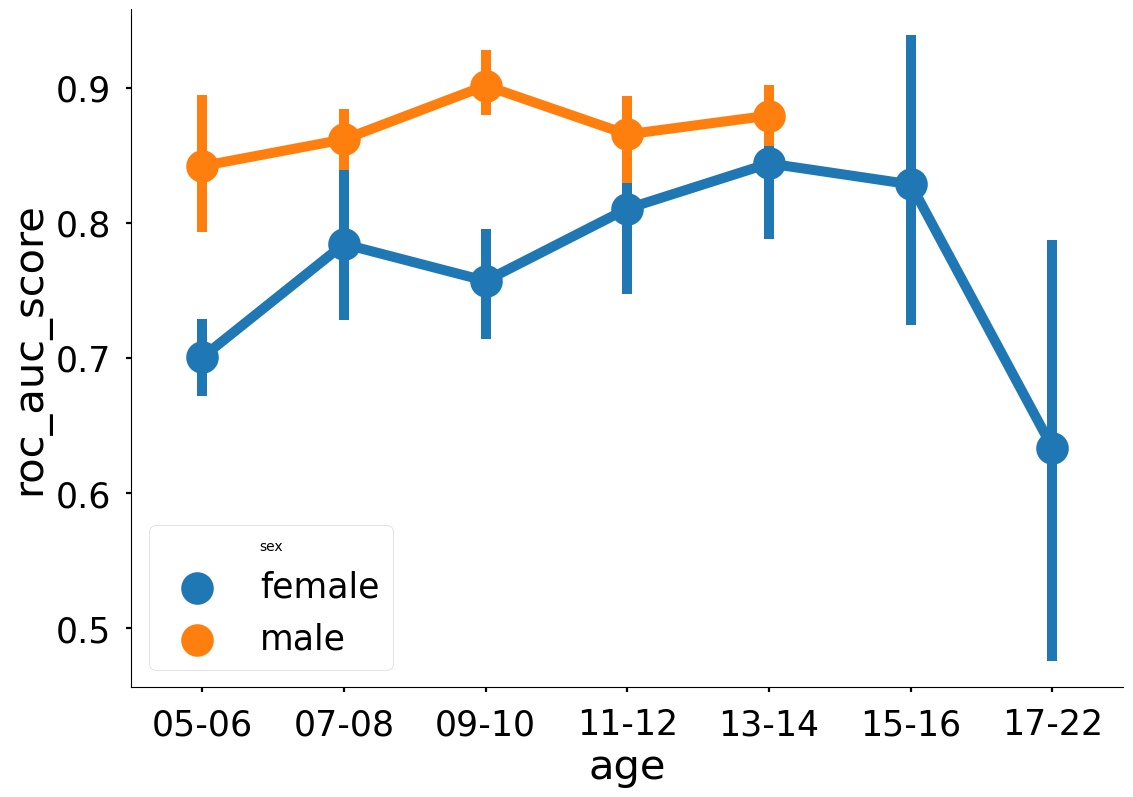

In [7]:
ages_to_keep = ['05-06', '07-08', '09-10', '11-12', '13-14', '15-16', '17-22']


df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
             (df_all['data']=='data') &
             (df_all['age'].isin(ages_to_keep)) &
             (df_all['assessment']=='Child Measures')
            ]

sns.pointplot(x='age', y='roc_auc_score', hue='sex', data=df1, order=sorted(df1['age'].unique()))

## Classifying ADHD from other diagnoses (all participants)

In these models, ADHD is classified from a number of diagnoses (ASD, Depression, No Diagnosis etc.).
* Parent Measures: Males are always etter classified than females except for ADHD/ASD in which females are better classified
* Child Measures: same result for child measurse, except that females are only slightly better than males when classifying ADHD/ASD
* Teacher Measures: no sig. difference between males and females for both classifications except ADHD/ASD where females are better classified

In [17]:
# get data
df_all = get_data(dirn='/Users/maedbhking/Documents/hbn_data/', 
                 models=['adhd-basic_demographics-models'])

df_all['category_new'] = df_all['category'].str.replace('ADHD_', '').str.replace('_ADHD', '')


In [190]:

to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
           'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given']

# loop over assessments
for assessment in ['Parent Measures', 'Child Measures', 'Teacher Measures', 'all']:
    df1 = df_all[(df_all['sex'].isin(['all'])) &
                 (df_all['data']=='data') &
                 (df_all['assessment']==assessment) &
                 (df_all['category_new'].isin(to_keep))
                ].reset_index(drop=True)

    ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='model_name', data=df1)
    plt.xticks(rotation=45, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f'ADHD - {assessment}')
    plt.axhline(y=0.5, color='k', linestyle='--')
    ax.set_ylim([0.4, 1])
    plt.show()

## Classification of ADHD for males and females (across different diagnoses)

## Classifying ADHD from other diagnoses

In these models, ADHD is classified from a number of diagnoses (ASD, Depression, No Diagnosis etc.).
* Parent Measures: Males are always etter classified than females except for ADHD/ASD in which females are better classified
* Child Measures: same result for child measurse, except that females are only slightly better than males when classifying ADHD/ASD
* Teacher Measures: no sig. difference between males and females for both classifications except ADHD/ASD where females are better classified

In [66]:
to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
           'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given']

# loop over assessments
for assessment in ['Parent Measures', 'Child Measures', 'Teacher Measures', 'all']:
    df1 = df_all[(df_all['sex'].isin(['male', 'female'])) &
                 (df_all['data']=='data') &
                 (df_all['assessment']==assessment) &
                 (df_all['category_new'].isin(to_keep))
                ].reset_index(drop=True)


    ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='sex', split=True, data=df1)
    plt.xticks(rotation=45, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f'ADHD - {assessment}')
    plt.axhline(y=0.5, color='k', linestyle='--')
    ax.set_ylim([0.4, 1])
    plt.show()


## Check Multiple Classifiers for basic ADHD (incl. demographics) model

In [21]:
# get data
df_all = get_data(dirn='/Users/maedbhking/Documents/hbn_data',
                 models=['adhd-basic_demographics-multiple-classifiers-models'],
                 )

df_all['category_new'] = df_all['category'].str.replace('ADHD_', '').str.replace('_ADHD', '')

to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
           'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given']

df_all.loc[~df_all['category_new'].isin(to_keep), 'category_new'] = 'All Other Diagnoses'


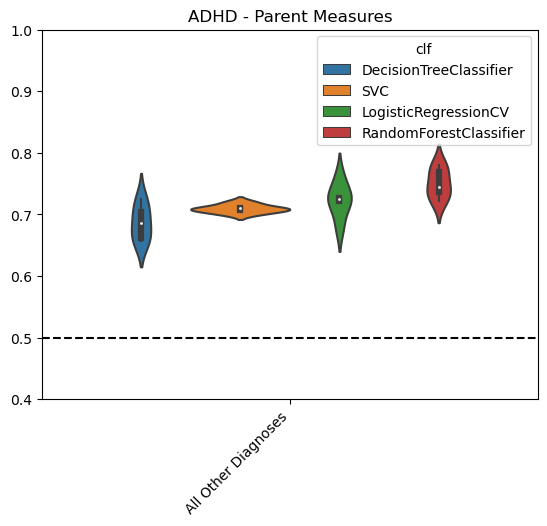

ValueError: min() arg is an empty sequence

In [51]:
to_keep = ['Depressive Disorders', 'Anxiety Disorders', 'Autism Spectrum Disorder', 
           'Specific Learning Disorder with Impairment in Reading', 'No Diagnosis Given', 'All Other Diagnoses']

# loop over assessments
for assessment in ['Parent Measures', 'Child Measures', 'Teacher Measures', 'all']:
    df1 = df_all[(df_all['sex'].isin(['male'])) &
                 (df_all['data']=='data') &
                 (df_all['assessment']==assessment) &
                 (df_all['category_new'].isin(to_keep))
                ].reset_index(drop=True)


    ax = sns.violinplot(x='category_new', y='roc_auc_score', hue='clf', data=df1)
    plt.xticks(rotation=45, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(f'ADHD - {assessment}')
    plt.axhline(y=0.5, color='k', linestyle='--')
    ax.set_ylim([0.4, 1])
    plt.show()

## Check ADHD Secondlevel Models

In [9]:
# get data
df_all = get_data(dirn='/Users/maedbhking/Documents/hbn_data/', 
                 models=['adhd-secondlevel-basic_demographics-models'])

  
df_all['participant_group'] = df_all['sex'] + '_' + df_all['age']
df_all['category_new'] = df_all['category'].str.replace('ADHD_', '').str.replace('_ADHD', '')

In [10]:
df_all['category_new'].unique()

array(['Autism Spectrum Disorder'], dtype=object)